# Results of the trained models

Evaluates the 4 final models on the train, val and test videos: one table per split, then three charts.

| model | backbone | trained on top |
|---|---|---|
| plain DINOv2 + heads | plain DINOv2, frozen | tool head + phase TCN |
| our DINO + heads | our Stage 1 DINO, frozen | tool head + phase TCN |
| plain DINOv2 + LoRA | plain DINOv2 + LoRA | LoRA + tool head; phase TCN on its features |
| our DINO + LoRA | our Stage 1 DINO + LoRA | LoRA + tool head; phase TCN on its features |

The outputs saved in this notebook are those of the final models, whose weights are not part of the repository. To
run it yourself, train the models with `run.py` and set `MODELS` below to the run folder. The first run extracts
the features of all 80 videos for each model into `<MODELS>/features/` (10-15 min); later runs reuse them.

In [ ]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"  # GPU numbers as in nvidia-smi

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Patch

import data
import evaluate

MODELS = Path("runs/run1")                  # the run folder of run.py (trained models)
FRAMES = MODELS / "frames"                  # frames made by extract_frames.py
ANNOTATIONS = Path("/path/to/cholec80")     # contains phase_annotations/ and tool_annotations/
DEVICE = "cuda:0"

In [2]:
results = evaluate.evaluate(MODELS, FRAMES, ANNOTATIONS, DEVICE)

all files match SHA256SUMS
train done
val done
test done


In [3]:
NAMES = {"baseline": "plain DINOv2 + heads", "stage1": "our DINO + heads",
         "baseline_lora": "plain DINOv2 + LoRA", "stage1_lora": "our DINO + LoRA"}

for split in ["train", "val", "test"]:
    rows = [f"### {split}", "", "| model | tool mAP | phase accuracy (strict) | phase accuracy (relaxed) |", "|---|---|---|---|"]
    for name, r in results[split].items():
        rows.append(f"| {NAMES[name]} | {r['tool_mAP']:.3f} | {100 * r['phase_strict_accuracy']:.1f}% | "
                    f"{100 * r['phase_relaxed_accuracy']:.1f}% |")
    display(Markdown("\n".join(rows)))

### train

| model | tool mAP | phase accuracy (strict) | phase accuracy (relaxed) |
|---|---|---|---|
| plain DINOv2 + heads | 1.000 | 99.4% | 99.6% |
| our DINO + heads | 1.000 | 99.5% | 99.7% |
| plain DINOv2 + LoRA | 0.999 | 99.8% | 99.9% |
| our DINO + LoRA | 0.999 | 99.9% | 99.9% |

### val

| model | tool mAP | phase accuracy (strict) | phase accuracy (relaxed) |
|---|---|---|---|
| plain DINOv2 + heads | 0.873 | 89.3% | 90.8% |
| our DINO + heads | 0.867 | 88.8% | 90.2% |
| plain DINOv2 + LoRA | 0.946 | 89.2% | 90.4% |
| our DINO + LoRA | 0.971 | 93.8% | 94.9% |

### test

| model | tool mAP | phase accuracy (strict) | phase accuracy (relaxed) |
|---|---|---|---|
| plain DINOv2 + heads | 0.838 | 82.2% | 83.3% |
| our DINO + heads | 0.844 | 84.3% | 85.4% |
| plain DINOv2 + LoRA | 0.911 | 85.1% | 85.9% |
| our DINO + LoRA | 0.928 | 88.0% | 88.7% |

In [4]:
# chart style: categorical colors in a fixed order (colorblind-checked default palette), quiet grid and axes
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({"figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#c3c2b7",
                     "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": GRID,
                     "grid.linewidth": 0.8, "axes.axisbelow": True, "font.size": 10, "legend.frameon": False})

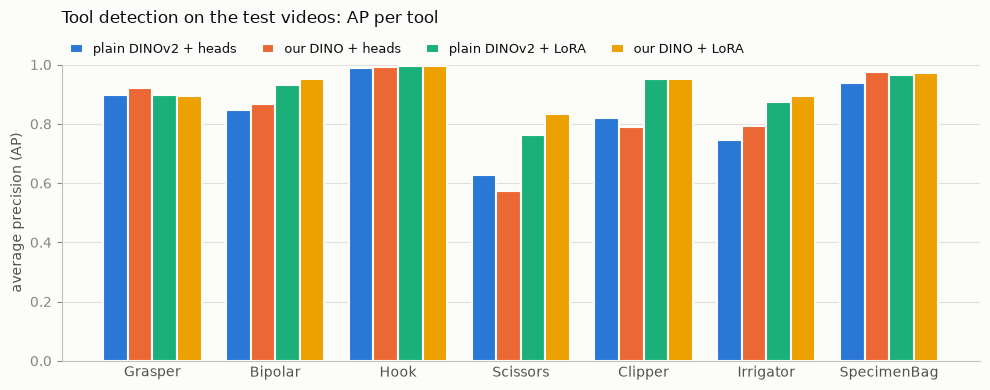

In [5]:
# AP per tool on the test videos: where do the differences between the models come from?
tools = list(results["test"]["baseline"]["tool_ap"])
x = np.arange(len(tools))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 4))
for i, (name, label) in enumerate(NAMES.items()):
    ap = [results["test"][name]["tool_ap"][t] for t in tools]
    ax.bar(x + (i - 1.5) * width, ap, width, label=label, color=SERIES[i], edgecolor=SURFACE, linewidth=1.5)
ax.set_xticks(x, tools)
ax.tick_params(axis="x", colors=INK2, length=0)
ax.set_ylim(0, 1)
ax.set_ylabel("average precision (AP)")
ax.grid(axis="x", visible=False)
ax.set_title("Tool detection on the test videos: AP per tool", loc="left", color=INK, fontsize=12, pad=30)
ax.legend(ncols=4, loc="lower left", bbox_to_anchor=(0, 1.0), fontsize=9, handlelength=1, borderaxespad=0.3)
fig.tight_layout()
plt.show()

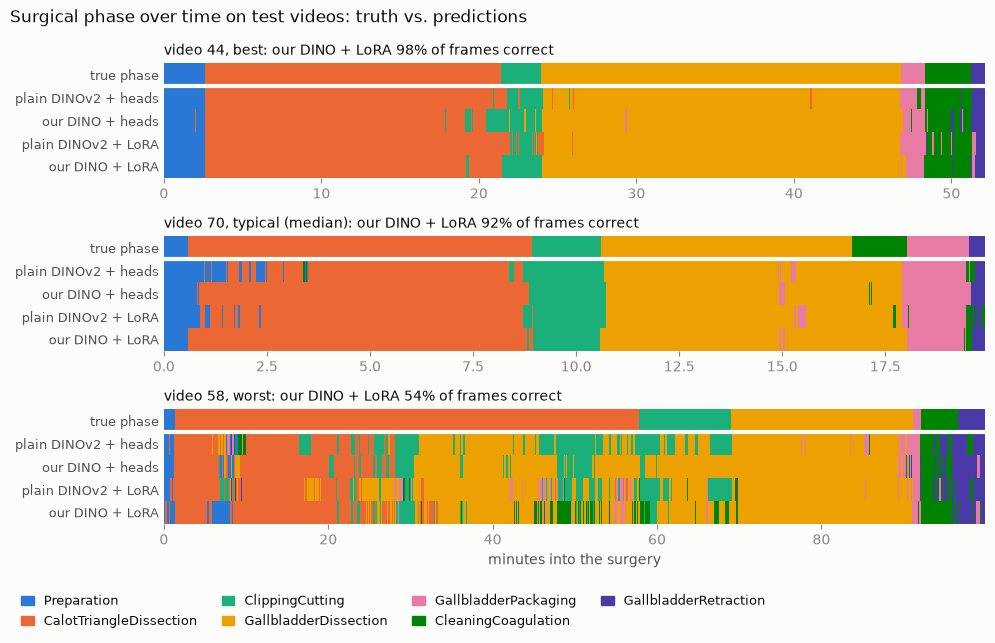

In [6]:
# Phase over time on 3 test videos: the true phases and each model's prediction (causal TCN, seed 0).
# The videos are chosen by our best model (our DINO + LoRA): its best, median and worst video.
preds = {name: evaluate.phase_predictions(MODELS, name, data.TEST, DEVICE) for name in NAMES}
acc = {v: (gt == pr).float().mean().item() for v, (gt, pr) in preds["stage1_lora"].items()}
by_acc = sorted(acc, key=acc.get)
videos = {"best": by_acc[-1], "typical (median)": by_acc[len(by_acc) // 2], "worst": by_acc[0]}

cmap = ListedColormap(SERIES[:len(data.PHASES)])
rows = ["true phase"] + list(NAMES.values())
fig, axes = plt.subplots(len(videos), 1, figsize=(10, 2.1 * len(videos)))
for ax, (kind, v) in zip(axes, videos.items()):
    gt = preds["stage1_lora"][v][0]
    strip = np.stack([gt.numpy()] + [preds[name][v][1].numpy() for name in NAMES])
    ax.imshow(strip, aspect="auto", cmap=cmap, vmin=-0.5, vmax=len(data.PHASES) - 0.5, interpolation="nearest",
              extent=(0, len(gt) / 60, len(rows) - 0.5, -0.5))  # 1 frame per second -> minutes
    ax.axhline(0.5, color=SURFACE, linewidth=3)  # gap between the truth and the predictions
    ax.set_yticks(range(len(rows)), rows, fontsize=9)
    ax.tick_params(axis="y", colors=INK2, length=0)
    ax.grid(False)
    ax.spines[["left", "bottom"]].set_visible(False)
    ax.set_title(f"video {v}, {kind}: our DINO + LoRA {100 * acc[v]:.0f}% of frames correct", loc="left", fontsize=10)
axes[-1].set_xlabel("minutes into the surgery")
fig.legend(handles=[Patch(color=SERIES[i], label=p) for i, p in enumerate(data.PHASES)], ncols=4, loc="lower left",
           bbox_to_anchor=(0.01, -0.02), fontsize=9, handlelength=1)
fig.suptitle("Surgical phase over time on test videos: truth vs. predictions", x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

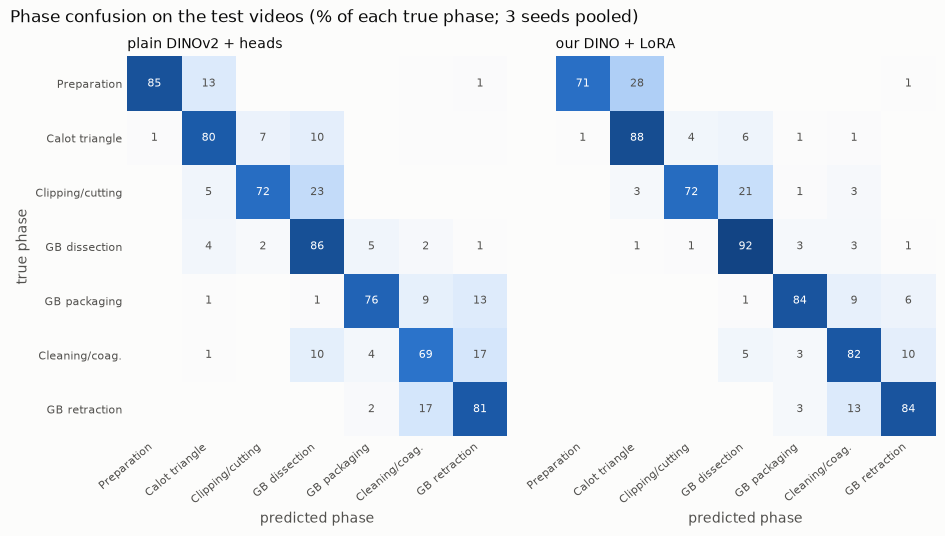

In [8]:
# Which phases get confused? Rows = true phase, columns = predicted phase, in % of the true phase's frames,
# on the test videos with all 3 TCN seeds pooled. Plain DINOv2 + heads next to our DINO + LoRA.
SHORT = ["Preparation", "Calot triangle", "Clipping/cutting", "GB dissection", "GB packaging", "Cleaning/coag.", "GB retraction"]
BLUES = LinearSegmentedColormap.from_list("blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
n = len(data.PHASES)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 5.2))
for ax, name in zip(axes, ["baseline", "stage1_lora"]):
    counts = torch.zeros(n, n)
    for seed in range(3):
        for gt, pr in evaluate.phase_predictions(MODELS, name, data.TEST, DEVICE, seed).values():
            counts += torch.bincount(gt * n + pr, minlength=n * n).reshape(n, n)
    share = (counts / counts.sum(1, keepdim=True)).numpy()
    ax.imshow(share, cmap=BLUES, vmin=0, vmax=1)
    for i in range(n):
        for j in range(n):
            if share[i, j] >= 0.005:  # leave cells below 0.5% empty
                ax.text(j, i, f"{100 * share[i, j]:.0f}", ha="center", va="center", fontsize=8,
                        color="#ffffff" if share[i, j] > 0.5 else INK2)
    ax.set_xticks(range(n), SHORT, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(n), SHORT if ax is axes[0] else [], fontsize=8)
    ax.tick_params(length=0, colors=INK2)
    ax.grid(False)
    ax.spines[["left", "bottom"]].set_visible(False)
    ax.set_xlabel("predicted phase")
    ax.set_title(NAMES[name], loc="left", fontsize=10)
axes[0].set_ylabel("true phase")
fig.suptitle("Phase confusion on the test videos (% of each true phase; 3 seeds pooled)", x=0.01, ha="left", fontsize=12)
fig.tight_layout()
plt.show()